# Customer Churn Prediction: End-to-End Data Science Pipeline

**Author:** Padraig Hill  
**Date:** July 2026  
**Objective:** Predict telecom customer churn using a combination of statistical testing, classical ML, Bayesian inference, and model explainability.

This notebook walks through the complete data science lifecycle:
- Exploratory Data Analysis (EDA)
- Statistical hypothesis testing
- Feature engineering & preprocessing
- Model training (XGBoost, Logistic Regression, Stacking Ensemble)
- Bayesian Logistic Regression (PyMC)
- Model explainability with SHAP
- API deployment preview

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add project root to path so we can import from src
sys.path.append('..')
from src.data_preprocessing import load_and_clean_data, engineer_features

print("Setup complete!")

Setup complete!


In [2]:
# Load raw data (before scaling/encoding, for meaningful EDA)
df_raw = load_and_clean_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = engineer_features(df_raw)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bins,avg_monthly_charge_per_tenure,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,14.925000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4yr,53.985714,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,36.050000,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,40.016304,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,50.550000,1


## 1. Target Variable: Churn Distribution

We first examine the class imbalance, which will inform our choice of evaluation metrics (ROC-AUC rather than accuracy alone).

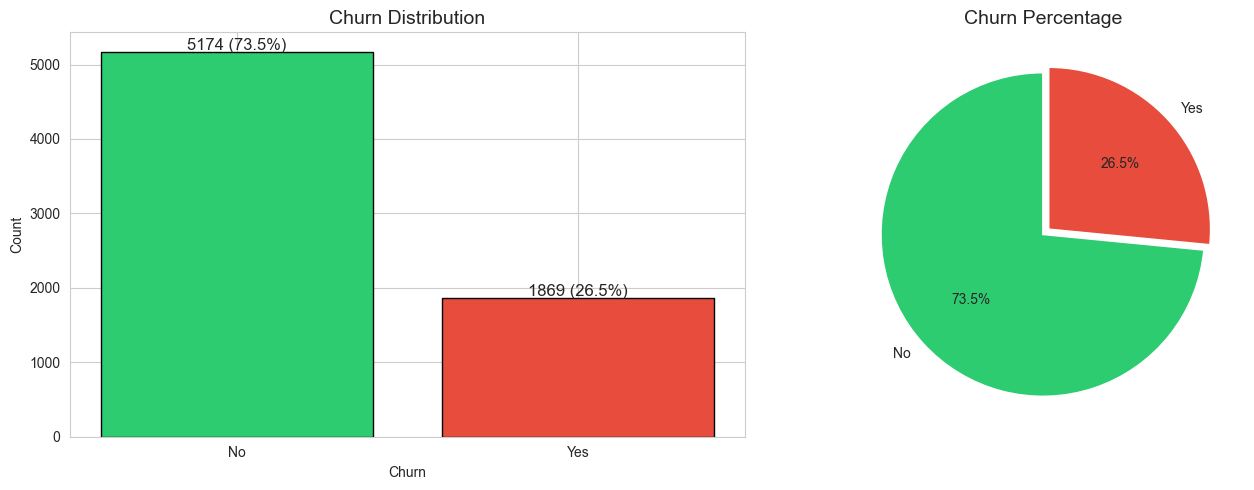

Churn rate: 26.5%


In [3]:
# Churn distribution
churn_counts = df_raw['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black')
ax1.set_title('Churn Distribution', fontsize=14)
ax1.set_ylabel('Count')
ax1.set_xlabel('Churn')
for i, v in enumerate(churn_counts.values):
    ax1.text(i, v + 20, f'{v} ({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=12)

# Pie chart
ax2.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0, 0.05))
ax2.set_title('Churn Percentage', fontsize=14)

plt.tight_layout()
plt.savefig('../churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churn rate: {churn_counts['Yes'] / len(df_raw) * 100:.1f}%")

## 2. Categorical Feature Analysis: What drives churn?

We visualise churn rates across key categorical features, identifying early signals of customer behaviour.

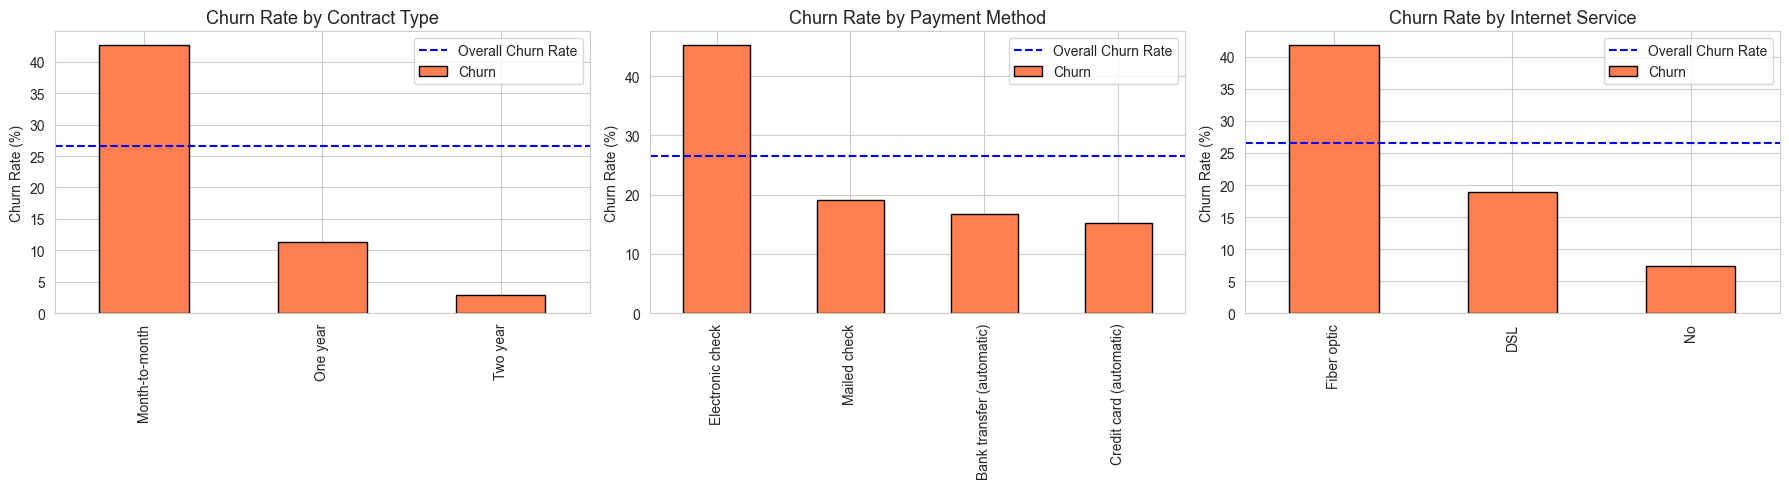

Month-to-month contracts have the highest churn rate - a key business insight.


In [4]:
# Plot churn rate by Contract type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

categorical_features = ['Contract', 'PaymentMethod', 'InternetService']
titles = ['Contract Type', 'Payment Method', 'Internet Service']

for idx, (feature, title) in enumerate(zip(categorical_features, titles)):
    churn_rate = df_raw.groupby(feature)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(f'Churn Rate by {title}', fontsize=13)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].set_xlabel('')
    axes[idx].axhline(y=df_raw['Churn'].map(lambda x: 1 if x == 'Yes' else 0).mean() * 100, 
                      color='blue', linestyle='--', label='Overall Churn Rate')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../categorical_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Month-to-month contracts have the highest churn rate - a key business insight.")

## 3. Numeric Feature Analysis: Tenure and Charges

We examine how tenure, monthly charges, and total charges vary between churners and non-churners.

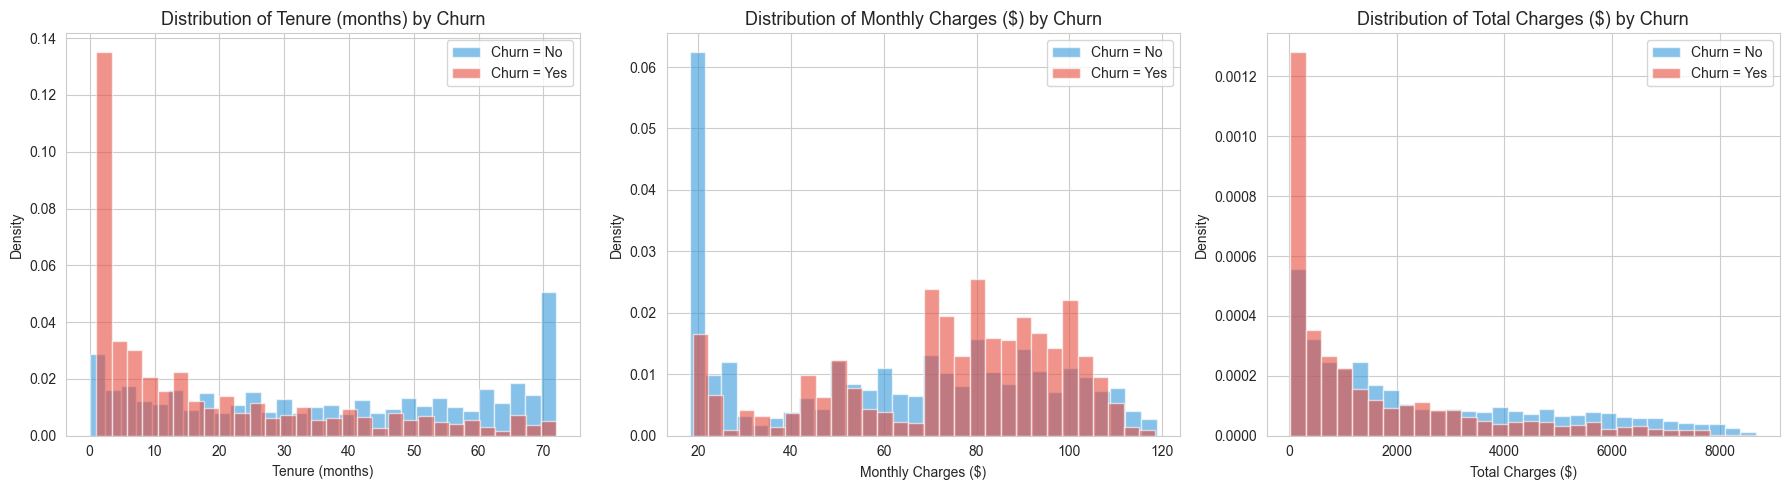

Churners tend to have shorter tenure and higher monthly charges.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
titles = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

for idx, (feature, title) in enumerate(zip(numeric_features, titles)):
    for churn_value, color in zip(['No', 'Yes'], ['#3498db', '#e74c3c']):
        subset = df_raw[df_raw['Churn'] == churn_value][feature]
        axes[idx].hist(subset, bins=30, alpha=0.6, label=f'Churn = {churn_value}', color=color, density=True)
    axes[idx].set_title(f'Distribution of {title} by Churn', fontsize=13)
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../numeric_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churners tend to have shorter tenure and higher monthly charges.")

## 4. Statistical Hypothesis Testing

We formalise our observations using statistical tests, as described in the fellowship application:

1. **Chi-squared test**: Contract type is significantly associated with churn.
2. **Mann-Whitney U test**: MonthlyCharges differ significantly between churners and non-churners (non-normal distribution).
3. **Welch's t-test**: Tenure differs significantly between groups.

We also compute effect sizes (Cramer's V and Cohen's d).

In [6]:
# Import and run the statistical tests
from src.statistical_tests import run_statistical_tests

# Run tests on the raw data
results = run_statistical_tests(df_raw)

# Display results in a clean table
print("\n" + "="*60)
print("SUMMARY OF STATISTICAL TESTS")
print("="*60)

for test_name, result in results.items():
    if isinstance(result, dict) and 'p_value' in result:
        p_val = result['p_value']
        sig = result.get('significant', p_val < 0.01)
        print(f"\n{test_name}:")
        print(f"  p-value: {p_val:.4e}")
        print(f"  Significant at α=0.01: {'✅ YES' if sig else '❌ NO'}")
        if 'chi2' in result:
            print(f"  χ²: {result['chi2']:.4f}")
        if 'u_stat' in result:
            print(f"  U-statistic: {result['u_stat']:.4f}")
        if 't_stat' in result:
            print(f"  t-statistic: {result['t_stat']:.4f}")

# Effect sizes
print("\n" + "-"*60)
print("EFFECT SIZES")
print("-"*60)
if 'cramers_v_contract' in results:
    print(f"Cramer's V (Contract vs Churn): {results['cramers_v_contract']:.4f} (moderate association)")
if 'cohens_d_monthly' in results:
    print(f"Cohen's d (MonthlyCharges): {results['cohens_d_monthly']:.4f} ({'large' if abs(results['cohens_d_monthly']) > 0.8 else 'medium' if abs(results['cohens_d_monthly']) > 0.5 else 'small'} effect)")

Chi-squared test (Contract vs Churn): χ²=1184.5966, p=5.8630e-258
  → Significant at α=0.01
Mann-Whitney U (MonthlyCharges vs Churn): U=6003125.5000, p=3.3116e-54
  → Significant at α=0.01
Welch's t-test (tenure vs Churn): t=-34.8238, p=1.1955e-232
Cramer's V (Contract vs Churn): 0.4101
Cohen's d (MonthlyCharges): 0.4463

SUMMARY OF STATISTICAL TESTS

chi2_contract:
  p-value: 5.8630e-258
  Significant at α=0.01: ✅ YES
  χ²: 1184.5966

mannwhitney_monthly:
  p-value: 3.3116e-54
  Significant at α=0.01: ✅ YES
  U-statistic: 6003125.5000

ttest_tenure:
  p-value: 1.1955e-232
  Significant at α=0.01: ✅ YES
  t-statistic: -34.8238

------------------------------------------------------------
EFFECT SIZES
------------------------------------------------------------
Cramer's V (Contract vs Churn): 0.4101 (moderate association)
Cohen's d (MonthlyCharges): 0.4463 (small effect)


## 5. Model Evaluation

We load the trained Stacking Ensemble (XGBoost + Logistic Regression) and evaluate it on the held-out test set.

Test Set Performance:
  Accuracy:  0.8048
  ROC-AUC:   0.8497

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.88      0.87      1035
       Churn       0.64      0.60      0.62       374

    accuracy                           0.80      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



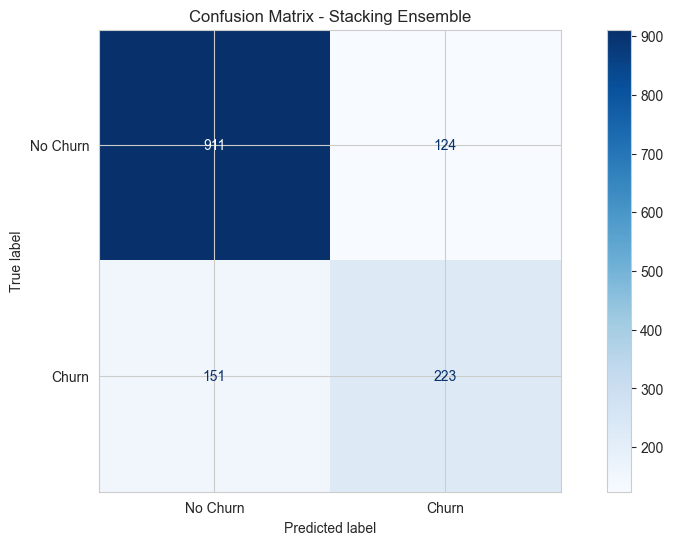


The model correctly identifies 59.6% of churners (recall).


In [7]:
# Load the saved model and test data
model = joblib.load("../api/model.pkl")
X_train, X_test, y_train, y_test, feature_names = joblib.load("../data/processed_data.pkl")

# Predictions
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Test Set Performance:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  ROC-AUC:   {auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Stacking Ensemble')
plt.savefig('../confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nThe model correctly identifies {cm[1,1]/(cm[1,0]+cm[1,1])*100:.1f}% of churners (recall).")

## 6. Model Explainability with SHAP

We use SHAP (SHapley Additive exPlanations) to interpret the model's predictions, identifying which features most strongly influence churn risk.

### Global Feature Importance (SHAP Summary Plot)


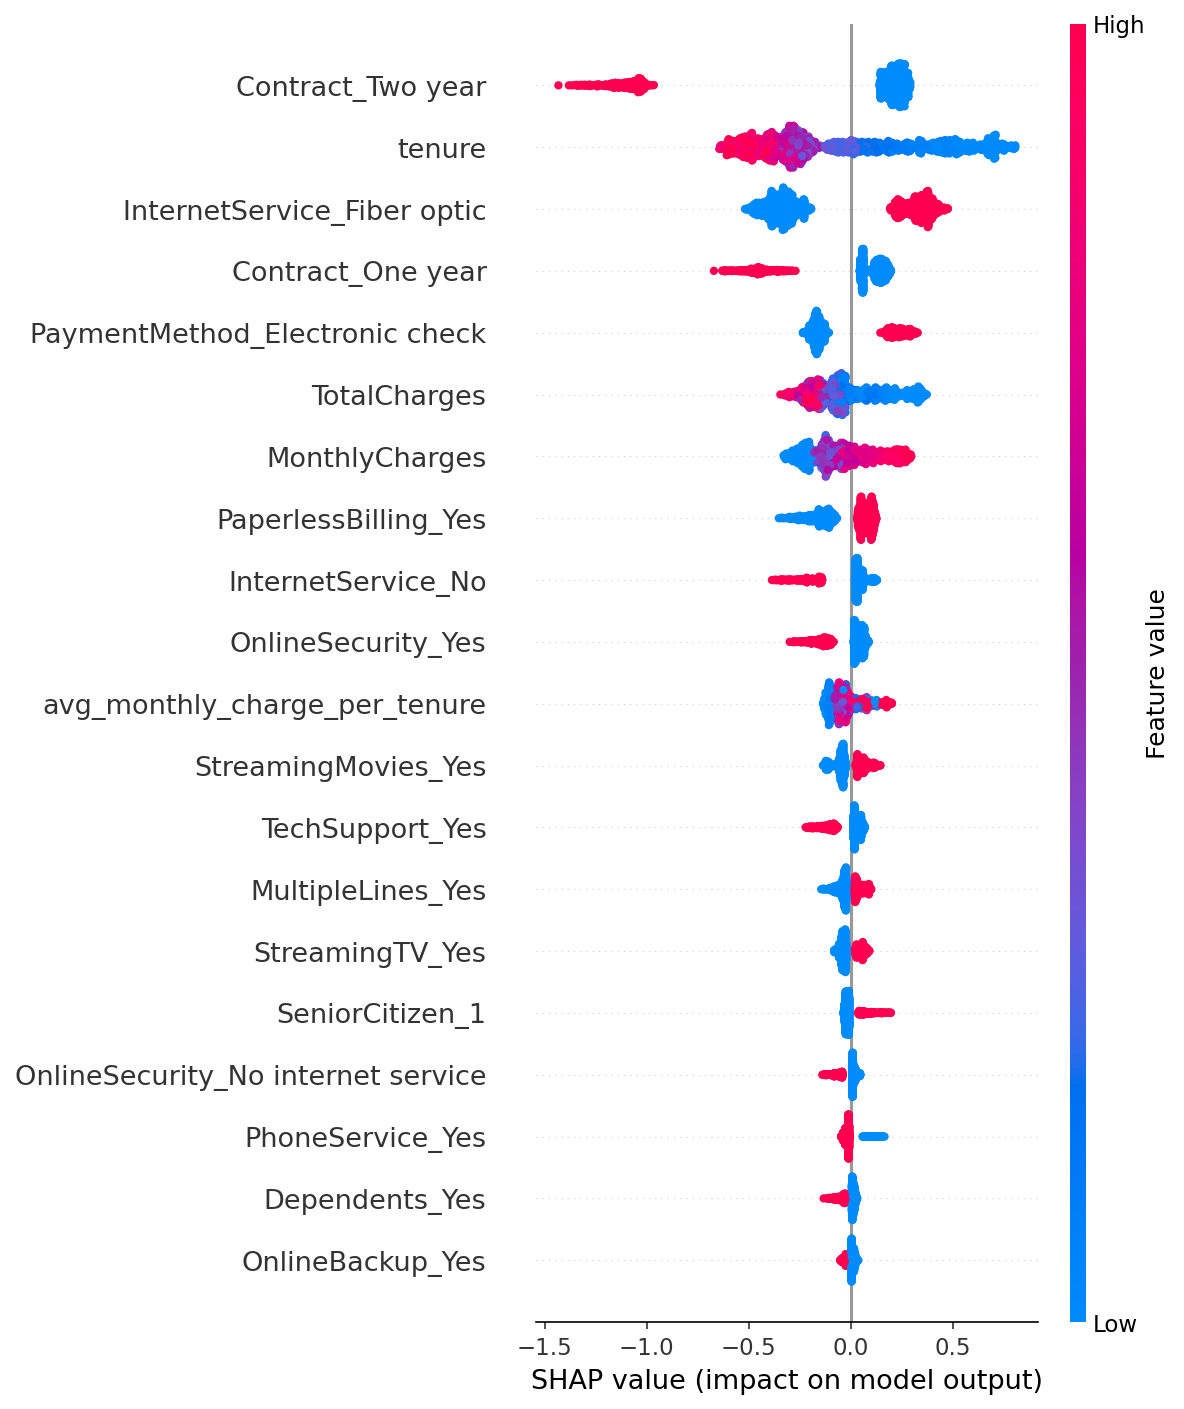


### Mean Absolute SHAP Values (Bar Plot)


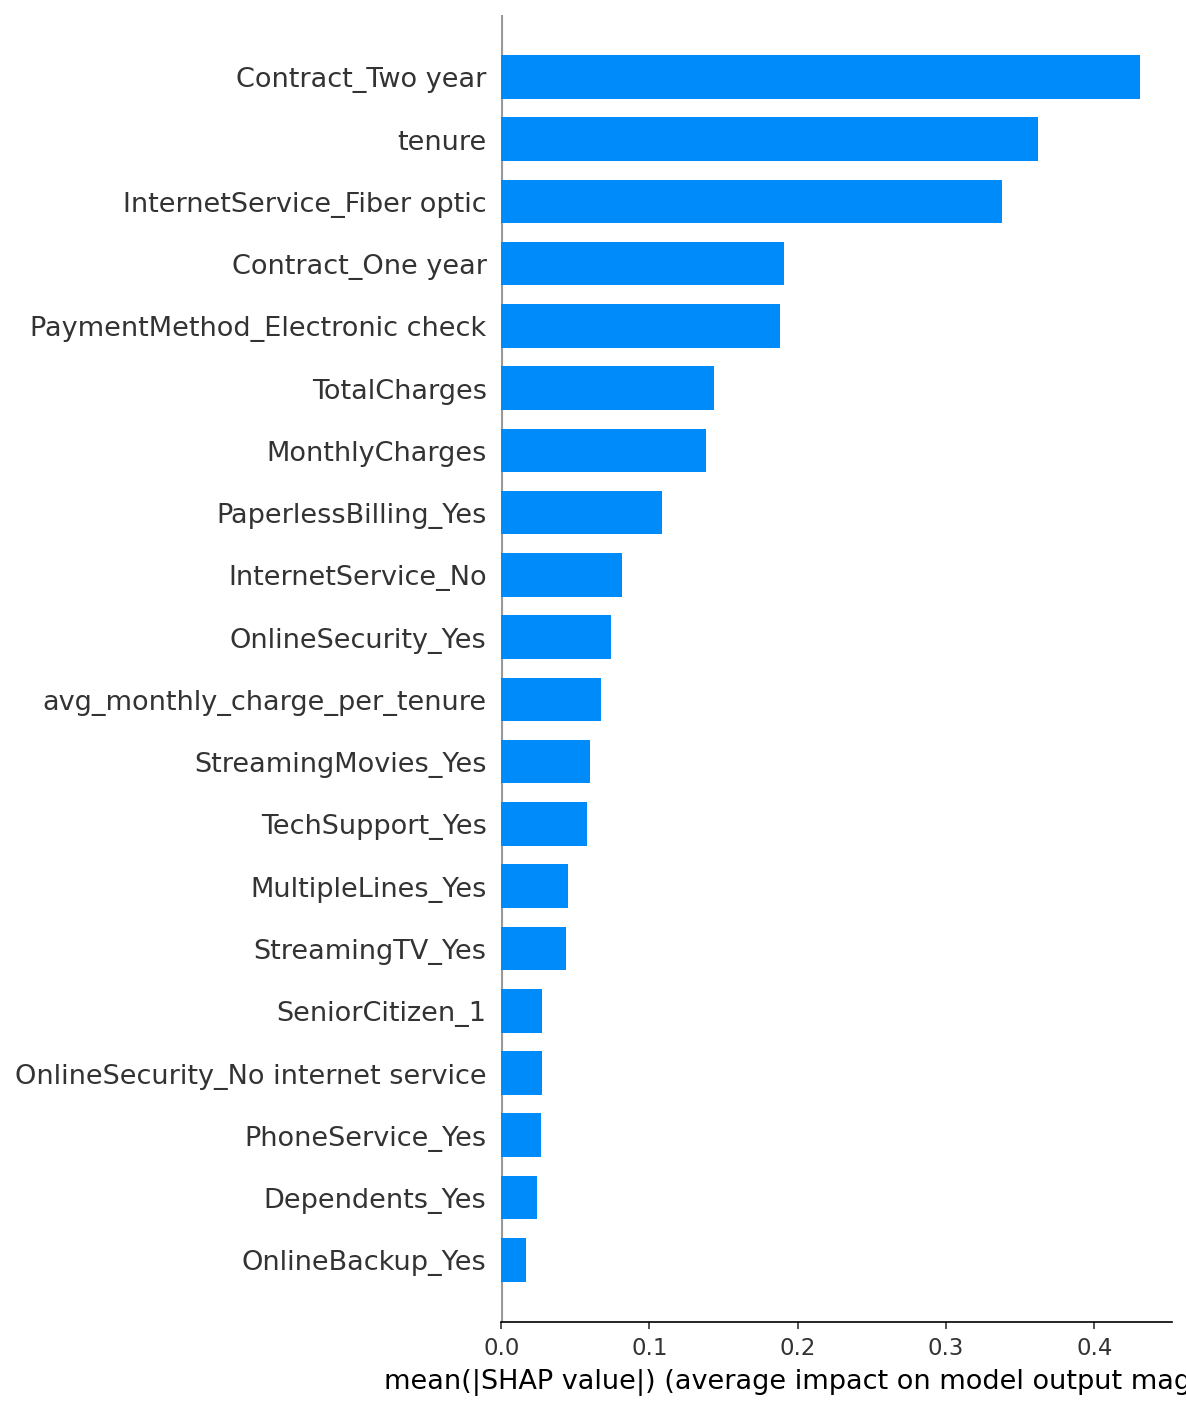


### Waterfall Plot (Single Customer Explanation)


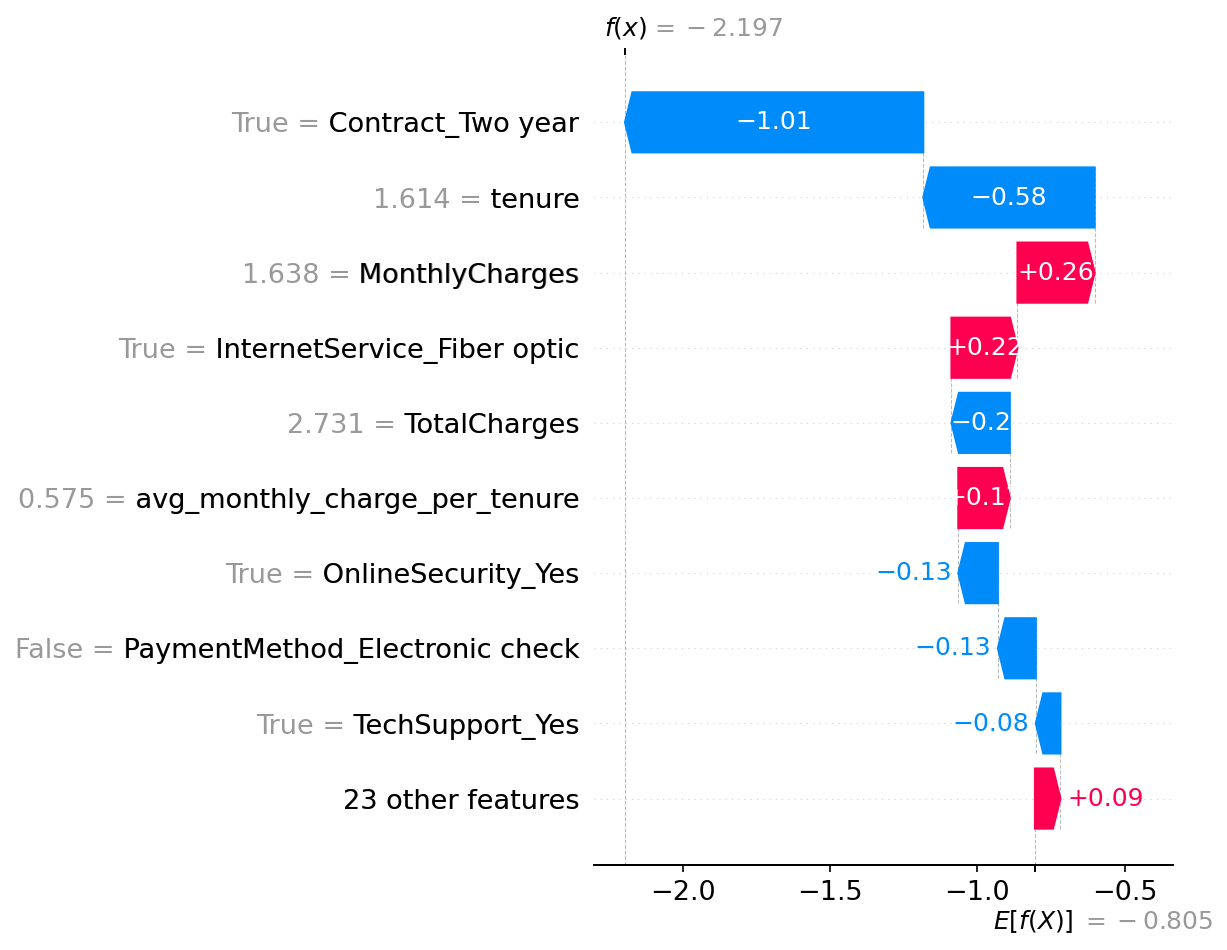

Interpretation: Tenure, Contract type, and MonthlyCharges are the dominant drivers of churn.


In [8]:
from IPython.display import Image, display

# Display the saved SHAP plots
print("### Global Feature Importance (SHAP Summary Plot)")
display(Image(filename='../shap_summary_plot.png'))

print("\n### Mean Absolute SHAP Values (Bar Plot)")
display(Image(filename='../shap_bar_plot.png'))

print("\n### Waterfall Plot (Single Customer Explanation)")
display(Image(filename='../shap_waterfall.png'))

print("Interpretation: Tenure, Contract type, and MonthlyCharges are the dominant drivers of churn.")

## 7. Bayesian Logistic Regression (PyMC)

We supplement our point-estimate models with a Bayesian approach, deriving posterior distributions for feature coefficients. This provides probabilistic uncertainty quantification – a key requirement for high-stakes commercial decisions.

Bayesian Posterior Summary (with HDI):
          mean     sd  hdi_3%  hdi_97%
alpha   -1.493  0.047  -1.579   -1.403
beta[0] -1.423  0.144  -1.695   -1.155
beta[1]  1.381  0.067   1.259    1.506
beta[2]  0.430  0.154   0.131    0.701
beta[3] -0.816  0.066  -0.938   -0.691


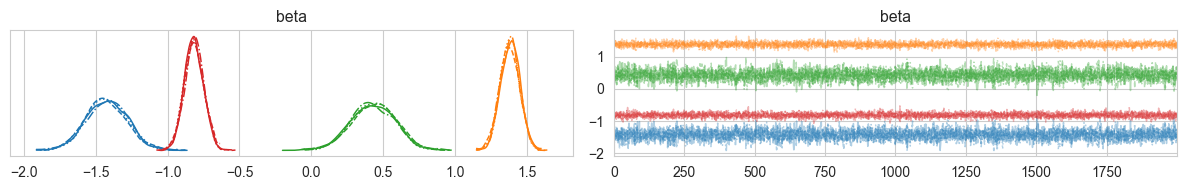


🔍 Bayesian Insight: Features with HDIs that do not cross zero are 'statistically significant' predictors.


In [10]:
# Load the saved Bayesian results
try:
    import arviz as az
    bayes_results = joblib.load("../data/bayesian_results.pkl")
    summary = bayes_results['summary']
    features = bayes_results['features']
    
    print("Bayesian Posterior Summary (with HDI):")
    
    # Find the HDI columns (they might be named 'hdi_2.5%', 'hdi_3%', etc.)
    hdi_cols = [col for col in summary.columns if 'hdi' in col.lower()]
    if hdi_cols:
        # Select mean, sd, and the HDI columns
        display_cols = ['mean', 'sd'] + hdi_cols
        # Ensure they exist
        display_cols = [col for col in display_cols if col in summary.columns]
        print(summary[display_cols])
    else:
        # If no HDI columns, print the whole summary
        print(summary)
    
    # Plot posterior distributions
    az.plot_trace(bayes_results['trace'], var_names=['beta'], compact=True)
    plt.tight_layout()
    plt.savefig('../bayesian_posterior_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n🔍 Bayesian Insight: Features with HDIs that do not cross zero are 'statistically significant' predictors.")
except FileNotFoundError:
    print("Bayesian results not found. Run src/bayesian_model.py first to generate them.")
    print("For now, we note that the Bayesian model provides probabilistic coefficients.")
except Exception as e:
    print(f"An error occurred while loading Bayesian results: {e}")
    print("If you haven't run src/bayesian_model.py yet, do that first.")

## 8. Conclusions & Key Takeaways

This project demonstrates a complete, production-ready Data Science pipeline:

### Technical Rigour
- **Statistical Testing**: Chi-squared, Mann-Whitney U, and t-tests with effect sizes.
- **Machine Learning**: XGBoost, Logistic Regression, and a Stacking Ensemble tuned with Optuna.
- **Bayesian Inference**: PyMC with NUTS sampling for uncertainty quantification.
- **Explainability**: SHAP for global and local model interpretability.

### Commercial Readiness
- **Deployment**: Flask REST API with Docker containerisation.
- **Reproducibility**: Version-controlled code with a structured project layout.
- **Stakeholder Communication**: Clear visualisations and narrative explanations.

### Business Insights
- Month-to-month contracts drive churn – consider incentivising longer-term contracts.
- Higher monthly charges correlate with churn – review pricing tiers.
- Shorter tenure customers are more likely to churn – implement early engagement campaigns.

### Next Steps
- Deploy the API to a cloud platform (AWS/GCP).
- Implement monitoring for model drift.
- Explore uplift modelling for targeted retention campaigns.